# Hydraulic Systems Modeling, Simulation and Control

Includes linearized and nonlinear hydraulic cylinder models, nonlinear valve-orifice flow, pump/supply pressure, return pressure, relief pressure, bulk modulus, leakage, cavitation warning, asymmetric areas, valve dynamics, accumulator, friction, stroke limits, PID anti-windup, state feedback, observer, LQR, digital control, Jacobian stability and uncertainty sweeps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.linalg as la
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

try:
    import control as ct
    HAS_CONTROL = True
except Exception as e:
    HAS_CONTROL = False
    print("Install python-control with: pip install control")
    print(e)

In [2]:
def stability_from_poles(poles, tol=1e-8):
    p=np.asarray(poles,dtype=complex)
    if np.any(np.real(p)>tol): return "UNSTABLE"
    if np.all(np.real(p)<-tol): return "ASYMPTOTICALLY STABLE"
    return "MARGINALLY STABLE"

def damping_label(zeta,tol=.02):
    if zeta < 0: return "UNSTABLE / NEGATIVE DAMPING"
    if abs(zeta)<1e-8: return "UNDAMPED"
    if zeta < 1-tol: return "UNDERDAMPED"
    if zeta <= 1+tol: return "CRITICALLY DAMPED (approximately)"
    return "OVERDAMPED"

def modal_label(poles):
    p=np.asarray(poles,dtype=complex)
    st=stability_from_poles(p)
    cp=[z for z in p if abs(np.imag(z))>1e-8]
    if cp:
        d=max(cp,key=lambda z:np.real(z))
        zeta=-np.real(d)/abs(d)
        if st=="UNSTABLE": return "OSCILLATORY UNSTABLE",st,zeta
        if zeta<.98: return "UNDERDAMPED",st,zeta
        if zeta<=1.02: return "CRITICALLY DAMPED-LIKE",st,zeta
        return "OVERDAMPED-LIKE",st,zeta
    return ("OVERDAMPED-LIKE / NON-OSCILLATORY" if st=="ASYMPTOTICALLY STABLE" else st),st,None

def metrics(t,y,final=None):
    t=np.asarray(t); y=np.asarray(y)
    if final is None: final=y[-1]
    peak_i=int(np.argmax(y)); peak=y[peak_i]
    overshoot=np.nan if abs(final)<1e-12 else max(0,(peak-final)/abs(final)*100)
    def cross(level):
        idx=np.where(y>=level)[0] if final>=0 else np.where(y<=level)[0]
        return t[idx[0]] if len(idx) else np.nan
    t10,t90=cross(.1*final),cross(.9*final)
    rise=t90-t10 if np.isfinite(t10) and np.isfinite(t90) else np.nan
    band=.02*max(abs(final),1e-12)
    out=np.where(np.abs(y-final)>band)[0]
    settle=0 if len(out)==0 else (t[out[-1]+1] if out[-1]<len(t)-1 else np.nan)
    return dict(rise_time=rise,settling_time=settle,peak_time=t[peak_i],overshoot_percent=overshoot,peak_value=peak)

def routh_table(coeffs):
    a=np.asarray(coeffs,float)
    n=len(a)-1; c=int(np.ceil((n+1)/2))
    R=np.zeros((n+1,c))
    R[0,:len(a[0::2])]=a[0::2]
    R[1,:len(a[1::2])]=a[1::2]
    eps=1e-9
    for i in range(2,n+1):
        if abs(R[i-1,0])<eps: R[i-1,0]=eps
        for j in range(c-1):
            R[i,j]=(R[i-1,0]*R[i-2,j+1]-R[i-2,0]*R[i-1,j+1])/R[i-1,0]
    s=np.sign(R[:,0]); changes=int(np.sum(s[:-1]*s[1:]<0))
    return R,changes

def jury_second_order(a):
    a0,a1,a2=map(float,a)
    cond={"|a2|<a0":abs(a2)<a0,"P(1)>0":a0+a1+a2>0,"P(-1)>0":a0-a1+a2>0}
    return cond,all(cond.values())

## Linearized hydraulic model

Classification: ('UNDERDAMPED', 'ASYMPTOTICALLY STABLE', np.float64(0.022448240265993923))
Poles: [-1.99857175e-04  +0.j         -6.14990007e+00+273.89008064j
 -6.14990007e+00-273.89008064j]
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.616e-13 s^2 - 1.019e-10 s + 7.5e+06
  -------------------------------------
    s^3 + 12.3 s^2 + 7.505e+04 s + 15
Ctrb: 3 Obsv: 3


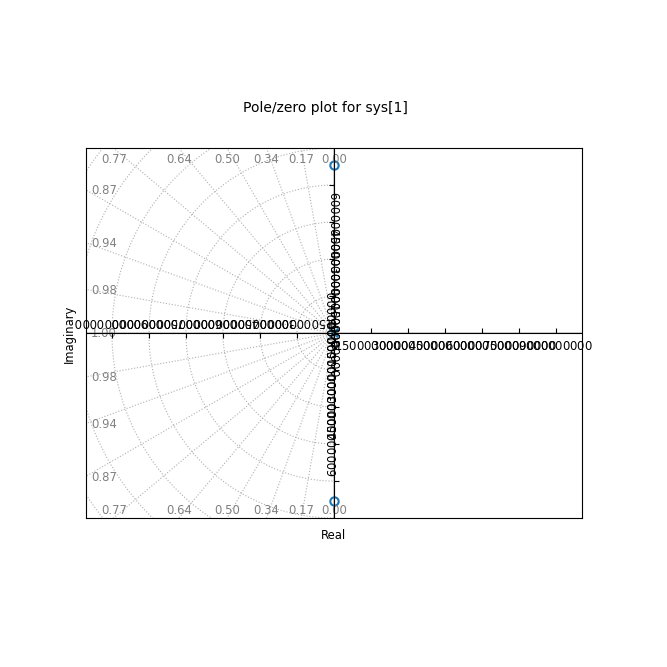

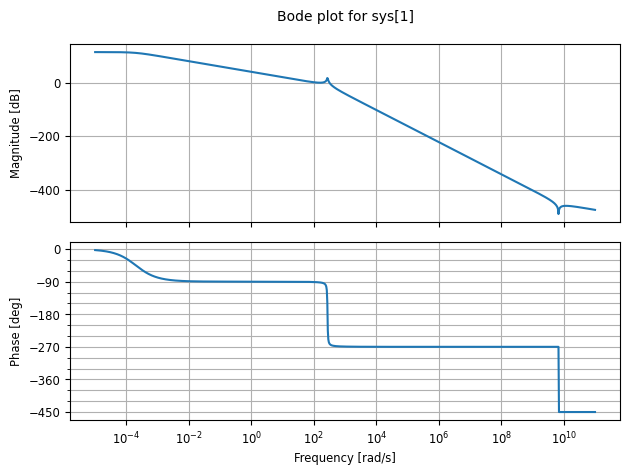

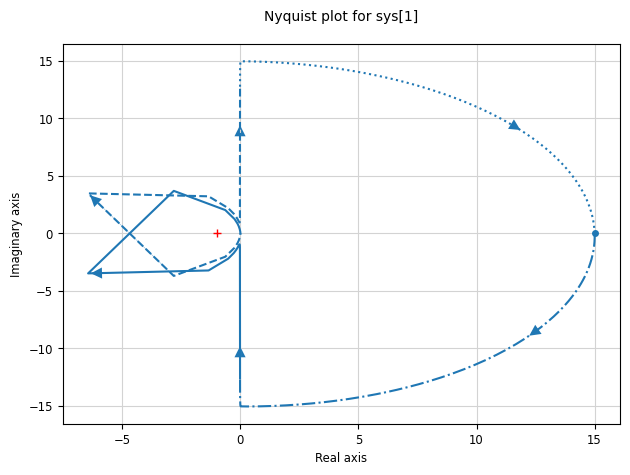

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


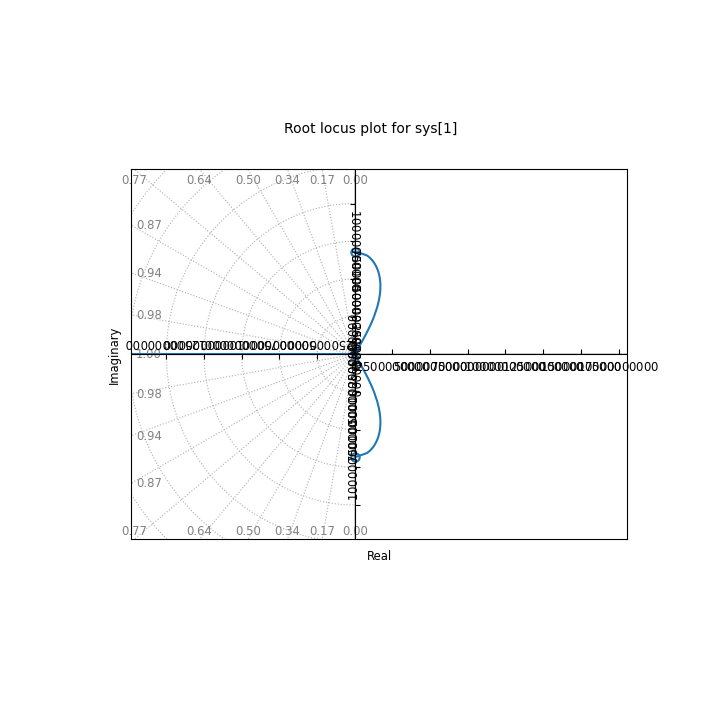

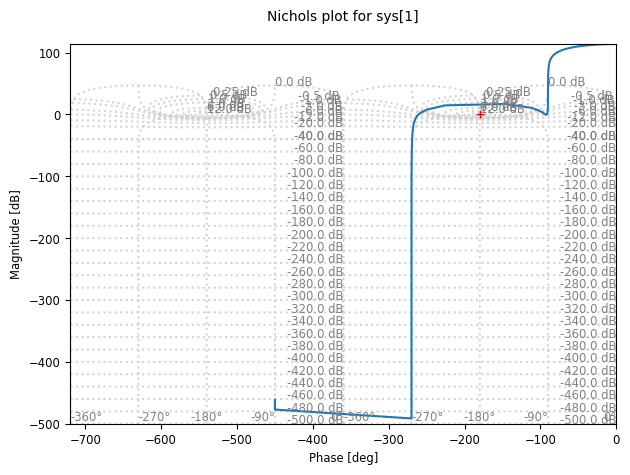

Margins: (np.float64(0.12308590399998957), np.float64(-80.69225895038336), np.float64(273.9591210381459), np.float64(314.0404962130453))
[[1.00000000e+00 7.50536000e+04]
 [1.23000000e+01 1.50000000e+01]
 [7.50523805e+04 0.00000000e+00]
 [1.50000000e+01 0.00000000e+00]]
RHP roots: 0


In [3]:
Ap=50e-4; m=100; b=1200; k=5000; beta=1.5e9; Vt=.01; Cl=2e-12
A=np.array([[0,1,0],[-k/m,-b/m,Ap/m],[0,-2*Ap*beta/Vt,-Cl*beta/Vt]])
B=np.array([[0],[0],[beta/Vt]]); C=np.array([[1,0,0]]); D=np.array([[0]])
p=np.linalg.eigvals(A); print("Classification:",modal_label(p)); print("Poles:",p)
if HAS_CONTROL:
    G=ct.ss2tf(ct.ss(A,B,C,D)); print(G); print("Ctrb:",np.linalg.matrix_rank(ct.ctrb(A,B)),"Obsv:",np.linalg.matrix_rank(ct.obsv(A,C)))
    ct.pzmap(G,grid=True); plt.show(); ct.bode_plot(G,dB=True,grid=True); plt.show(); ct.nyquist_plot(G); plt.show(); ct.root_locus_plot(G,grid=True); plt.show()
    try: ct.nichols_plot(G,grid=True); plt.show()
    except Exception as e: print(e)
    print("Margins:",ct.margin(G))
Rtab,chg=routh_table(np.poly(A)); print(Rtab); print("RHP roots:",chg)

## Nonlinear valve-cylinder model

In [4]:
def qor(dp,A,Cd=.65,rho=850): return Cd*A*np.sign(dp)*np.sqrt(2*abs(dp)/rho)

def hydraulic_nonlinear(supply_mpa=12,valve=.5,bore_mm=63,rod_mm=32,stroke=.5,dead_ml=80,mass=150,beta_gpa=1.4,leak=2e-12,tau_spool=.02,friction=300,relief_mpa=16,return_bar=1):
    Ps=supply_mpa*1e6; Pr=return_bar*1e5; relief=relief_mpa*1e6; bet=beta_gpa*1e9
    A1=np.pi*(bore_mm/1000)**2/4; A2=np.pi*((bore_mm/1000)**2-(rod_mm/1000)**2)/4
    Vd=dead_ml*1e-6; Amax=2e-5
    def f(t,y):
        x,v,P1,P2,z=y; dz=(np.clip(valve,-1,1)-z)/tau_spool; Av=Amax*abs(z); Psrc=min(Ps,relief)
        V1=max(Vd+A1*x,1e-7); V2=max(Vd+A2*(stroke-x),1e-7)
        if z>=0: Q1=qor(Psrc-P1,Av); Q2=qor(P2-Pr,Av)
        else: Q1=-qor(P1-Pr,Av); Q2=-qor(Psrc-P2,Av)
        Ql=leak*(P1-P2)
        dP1=bet/V1*(Q1-A1*v-Ql); dP2=bet/V2*(A2*v-Q2+Ql)
        Fh=P1*A1-P2*A2-Pr*(A1-A2); acc=(Fh-friction*np.tanh(120*v))/mass
        if x<=0 and v<0: acc=max(acc,0)
        if x>=stroke and v>0: acc=min(acc,0)
        return [v,acc,dP1,dP2,dz]
    t=np.linspace(0,2,2200); sol=solve_ivp(f,[0,2],[stroke*.3,0,Pr,Pr,0],t_eval=t,method="Radau")
    print("Minimum pressure:",min(sol.y[2].min(),sol.y[3].min())/1e5,"bar abs")
    if min(sol.y[2].min(),sol.y[3].min())<.2e5: print("WARNING: cavitation risk")
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[0]); plt.axhline(stroke,ls="--"); plt.grid(True); plt.show()
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[2]/1e6,label="P1"); plt.plot(t,sol.y[3]/1e6,label="P2"); plt.grid(True); plt.legend(); plt.show()
widgets.interact(hydraulic_nonlinear,supply_mpa=(3.,25.,1.),valve=(-1.,1.,.1),bore_mm=(25.,125.,1.),rod_mm=(10.,70.,1.),stroke=(.1,1.,.05),dead_ml=(10.,300.,10.),mass=(20.,500.,10.),beta_gpa=(.3,2.2,.1),leak=widgets.FloatLogSlider(value=2e-12,base=10,min=-13,max=-9,step=.1),tau_spool=(.005,.1,.005),friction=(0.,1500.,50.),relief_mpa=(5.,30.,1.),return_bar=(.5,5.,.5));

interactive(children=(FloatSlider(value=12.0, description='supply_mpa', max=25.0, min=3.0, step=1.0), FloatSli…

## Accumulator model

In [5]:
def accumulator(P0=8,V0=5,n=1.4,Vfluid=1):
    V=(V0-Vfluid)/1000
    if V<=0: print("Invalid"); return
    P=P0*1e6*((V0/1000)/V)**n
    print("Accumulator pressure:",P/1e6,"MPa")
widgets.interact(accumulator,P0=(1.,20.,1.),V0=(1.,20.,1.),n=(1.,1.4,.05),Vfluid=(0.,4.,.1));

interactive(children=(FloatSlider(value=8.0, description='P0', max=20.0, min=1.0, step=1.0), FloatSlider(value…

## PID anti-windup and flow saturation

In [ ]:
def hyd_pid(Kp=2e-4,Ki=5e-5,Kd=1e-5,ref=.15,qlim_lpm=60):
    qlim=qlim_lpm/60000
    def f(t,y):
        x,v,dp,I=y; e=ref-x; qr=Kp*e+Ki*I-Kd*v; q=np.clip(qr,-qlim,qlim)
        return [v,(Ap*dp-b*v-k*x-5000)/m,(beta/Vt)*(q-2*Ap*v-Cl*dp),e+5*(q-qr)]
    t=np.linspace(0,3,1800); sol=solve_ivp(f,[0,3],[0,0,0,0],t_eval=t,method="Radau")
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[0]); plt.axhline(ref,ls="--"); plt.grid(True); plt.show()
widgets.interact(hyd_pid,Kp=widgets.FloatLogSlider(value=2e-4,base=10,min=-6,max=-2,step=.1),Ki=widgets.FloatLogSlider(value=5e-5,base=10,min=-7,max=-3,step=.1),Kd=widgets.FloatLogSlider(value=1e-5,base=10,min=-7,max=-3,step=.1),ref=(.02,.4,.02),qlim_lpm=(5.,150.,5.));

interactive(children=(FloatLogSlider(value=0.0002, description='Kp', max=-2.0, min=-6.0), FloatLogSlider(value…

## State feedback, observer, LQR and digital model

In [7]:
if HAS_CONTROL:
    Ksf=ct.place(A,B,[-20,-35,-50]); Lobs=ct.place(A.T,C.T,[-70,-80,-90]).T
    print("K:",Ksf); print("L:",Lobs)
    try: print("LQR:",ct.lqr(A,B,np.diag([100,2,1e-12]),np.array([[1e10]])))
    except Exception as e: print(e)
Ad,Bd,Cd,Dd,_=signal.cont2discrete((A,B,C,D),.005)
dp=np.linalg.eigvals(Ad); print("Discrete poles:",dp); print("Unit-circle stable?",np.all(abs(dp)<1))

K: [[ 4.04666511e-03 -9.69546667e-03  6.17999999e-10]]
L: [[ 2.27720787e+02]
 [-5.87511570e+04]
 [-3.31162681e+11]]
LQR: (array([[ 9.78048180e-05, -1.44952586e-07,  7.13842812e-13]]), array([[ 9.84560516e+03,  4.34218744e-02,  6.52032120e-06],
       [ 4.34218744e-02,  1.29488128e+00, -9.66350572e-09],
       [ 6.52032120e-06, -9.66350572e-09,  4.75895208e-14]]), array([-0.01004468  +0.j        , -6.19851587+273.88912291j,
       -6.19851587-273.88912291j]))
Discrete poles: [0.999999  +0.j         0.19393229+0.95012849j 0.19393229-0.95012849j]
Unit-circle stable? True


## Local Jacobian and uncertainty sweep

Jacobian:
 [[ 0.0e+00  1.0e+00  0.0e+00]
 [-5.0e+01 -1.2e+01  5.0e-05]
 [ 0.0e+00 -1.5e+09 -3.0e-01]]
Local poles: [-1.99857175e-04  +0.j         -6.14990007e+00+273.89008064j
 -6.14990007e+00-273.89008064j]


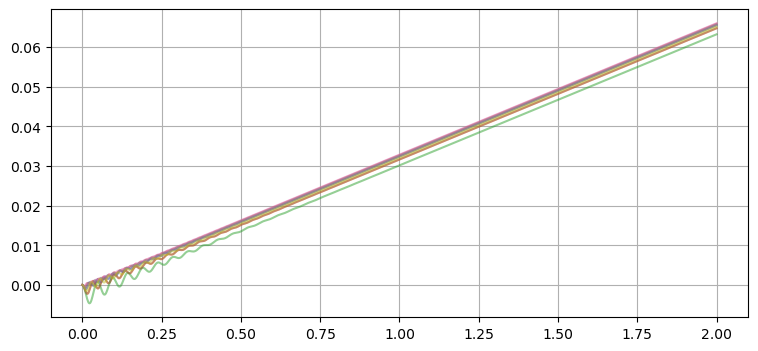

In [8]:
def simp(x):
    pos,v,dp=x; return np.array([v,(Ap*dp-b*v-k*pos)/m,(beta/Vt)*(-2*Ap*v-Cl*dp)])
x0=np.zeros(3); h=1e-6; J=np.zeros((3,3))
for i in range(3):
    xp=x0.copy(); xm=x0.copy(); xp[i]+=h; xm[i]-=h; J[:,i]=(simp(xp)-simp(xm))/(2*h)
print("Jacobian:\n",J); print("Local poles:",np.linalg.eigvals(J))

t=np.linspace(0,2,1200); plt.figure(figsize=(9,4))
for bg in [.7,1.4,2.0]:
    for Vl in [5,10,20]:
        bet=bg*1e9; V=Vl/1000
        def f(ti,y): x,v,dp=y; q=20/60000; return [v,(Ap*dp-b*v-k*x-5000)/m,(bet/V)*(q-2*Ap*v-Cl*dp)]
        sol=solve_ivp(f,[0,2],[0,0,0],t_eval=t,method="Radau"); plt.plot(t,sol.y[0],alpha=.5)
plt.grid(True); plt.show()